# ML Project: Student Dropout Prediction
## Notebook 01 :Exploratory Data Analysis (EDA)
**By : Nada Azzouz G5**  
**Dataset : Predict Students' Dropout and Academic Success UCI ML Repository (Portugal, 2021)**

---

## 1. Problem Definition

### Business context
University dropout represents a major human and financial cost for higher education institutions. In Europe, about 30 percent of students drop out before earning their degree.

### Technical objective
Build a **multi-classe classifier** that can predict, at the end of the first semester, whether a student will:
- **Dropout** -> urgent intervention needed
- **Remain enrolled** -> standard monitoring
- **Graduate** -> no action required

### ML formulation
- **Problem type** : supervised multi-class classification
- **Target variable** : Target (Dropout / Enrolled / Graduate)
- **features** : 35 academic, demographic, and socio-economic variables
- **Main metric** :weighted F1-score, suitable for class imbalance

### This notebook
This notebook covers only exploratory data analysis.
It does not include any model training.
The goal is to understand the data before transforming it.
Preprocessing decisions in Notebook 02 are based on the observations made here.

---
## 2. Importing Libraries

Only the libraries necessary for exploration are imported. No modeling libraries are used in this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

# global style for the graphics
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

# making colors for diffrent 3 classes
CLASS_COLORS = {
    'Dropout':  '#E74C3C',#red
    'Enrolled': '#F39C12',# Orange
    'Graduate': '#2ECC71',#green
}
PALETTE = list(CLASS_COLORS.values())

print('Librairies are successfully imported')

Librairies are successfully imported


---
## 3. Loading the Data

The dataset is loaded directly from the UCI repository using the ucimlrepo library. This approach guarantees **reproducibility** . Anyone can run this notebook without having the CSV file locally.

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

# Load from local CSV (used when UCI server is unavailable)
DATA_PATH = Path('..') / 'data' / 'student_dropout.csv'

# Try semicolon separator first (UCI format), fall back to comma
try:
    df = pd.read_csv(DATA_PATH, sep=';')
    # If it loaded as one single column, the separator was wrong
    if df.shape[1] == 1:
        df = pd.read_csv(DATA_PATH, sep=',')
except FileNotFoundError:
    raise FileNotFoundError(f'CSV not found at {DATA_PATH.resolve()} — check the file name and location')

print(f'Dataset loaded from local CSV')
print(f'   Path : {DATA_PATH.resolve()}')
print(f'   Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'\nTarget distribution:\n{df["Target"].value_counts()}')

Dataset loaded from local CSV
   Path : C:\Users\nadaa\OneDrive\Desktop\ml_project\data\student_dropout.csv
   Shape: 4424 rows × 37 columns

Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


---
## 4. General Overview of the Dataset

Before any analysis, we examine the overall structure of the dataset: data types, first rows, basic descriptive statistics.

In [3]:
#The first lines
print('First lines :')
display(df.head())

print('\nTypes of data :')
print(df.dtypes.value_counts())
print('\nColumn details :')
print(df.dtypes)

First lines :


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.000,1,19,12,5,9,127.300,1,0,0,1,1,0,20,0,0,0,0,0,0.000,0,0,0,0,0,0.000,0,10.800,1.400,1.740,Dropout
1,1,15,1,9254,1,1,160.000,1,1,3,3,3,142.500,1,0,0,0,1,0,19,0,0,6,6,6,14.000,0,0,6,6,6,13.667,0,13.900,-0.300,0.790,Graduate
2,1,1,5,9070,1,1,122.000,1,37,37,9,9,124.800,1,0,0,0,1,0,19,0,0,6,0,0,0.000,0,0,6,0,0,0.000,0,10.800,1.400,1.740,Dropout
3,1,17,2,9773,1,1,122.000,1,38,37,5,3,119.600,1,0,0,1,0,0,20,0,0,6,8,6,13.429,0,0,6,10,5,12.400,0,9.400,-0.800,-3.120,Graduate
4,2,39,1,8014,0,1,100.000,1,37,38,9,9,141.500,0,0,0,1,0,0,45,0,0,6,9,5,12.333,0,0,6,6,6,13.000,0,13.900,-0.300,0.790,Graduate



Types of data :
int64      29
float64     7
object      1
Name: count, dtype: int64

Column details :
Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance\t                        int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                     

In [4]:
print('Descriptive Statistics:')
display(df.describe().T.style
    .background_gradient(cmap='Blues', subset=['mean'])
    .background_gradient(cmap='Oranges', subset=['std'])
    .format('{:.3f}'))

Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
Marital status,4424.000,1.179,0.606,1.000,1.000,1.000,1.000,6.000
Application mode,4424.000,18.669,17.485,1.000,1.000,17.000,39.000,57.000
Application order,4424.000,1.728,1.314,0.000,1.000,1.000,2.000,9.000
Course,4424.000,8856.643,2063.566,33.000,9085.000,9238.000,9556.000,9991.000
Daytime/evening attendance,4424.000,0.891,0.312,0.000,1.000,1.000,1.000,1.000
Previous qualification,4424.000,4.578,10.217,1.000,1.000,1.000,1.000,43.000
Previous qualification (grade),4424.000,132.613,13.188,95.000,125.000,133.100,140.000,190.000
Nacionality,4424.000,1.873,6.915,1.000,1.000,1.000,1.000,109.000
Mother's qualification,4424.000,19.562,15.603,1.000,2.000,19.000,37.000,44.000
Father's qualification,4424.000,22.275,15.343,1.000,3.000,19.000,37.000,44.000


---
## 5. Missing Value Analysis

Missing values (NaN) must be identified before any processing. They can cause:
- **Run-time errors** during training (sklearn does not tolerate NaNs)
- **Statistical biases** if they are ignored or incorrectly replaced

The number and percentage of missing values are calculated for each column.

In [5]:
# Calculating missing values
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Number of NaN': missing_count,
    '% missing':    missing_pct
}).sort_values('Number of NaN', ascending=False)

cols_with_missing = missing_df[missing_df['Number of NaN'] > 0]

if len(cols_with_missing) == 0:
    print('No missing values were detected in the dataset')
else:
    print(f'{len(cols_with_missing)} columns have missing values:')
    display(cols_with_missing)

    # Visualisation
    fig, ax = plt.subplots(figsize=(10, 4))
    cols_with_missing['% missing'].plot(kind='barh', ax=ax, color='#E74C3C')
    ax.set_title('Percentage of missing values per column', fontweight='bold')
    ax.set_xlabel('% missing')
    plt.tight_layout()
    plt.show()

No missing values were detected in the dataset


---
## 6. Duplicate Detection

Exactly identical duplicate lines would bias the training: the model would memorize these lines rather than learning generalizable patterns. If a duplicate appears in both the training and the test, the evaluation metrics will be artificially inflated.

In [6]:
n_duplicates = df.duplicated().sum()
print(f'Number of duplicated lines: {n_duplicates}')
if n_duplicates > 0:
    pct = n_duplicates / len(df) * 100
    print(f'Represents {pct:.2f}% of the dataset')
    print('These lines will be deleted in Notebook 02')
    print('\nPreview of duplicates :')
    display(df[df.duplicated(keep=False)].head(10))
else:
    print('No duplicates detected')

Number of duplicated lines: 0
No duplicates detected


---
## 7. Target Variable Analysis

The distribution of the target variable is the first indicator of **class imbalance**. If a class is very rare, the model will tend to ignore it, which necessitates specific strategies (weighting, SMOTE, etc.).

Target variable distribution:


,Count,% of dataset
Target,,
Graduate,2209,49.900
Dropout,1421,32.100
Enrolled,794,17.900



Imbalance ratio (majority / minority) : 2.78x
Moderate imbalance. class_weight="balanced" recommended


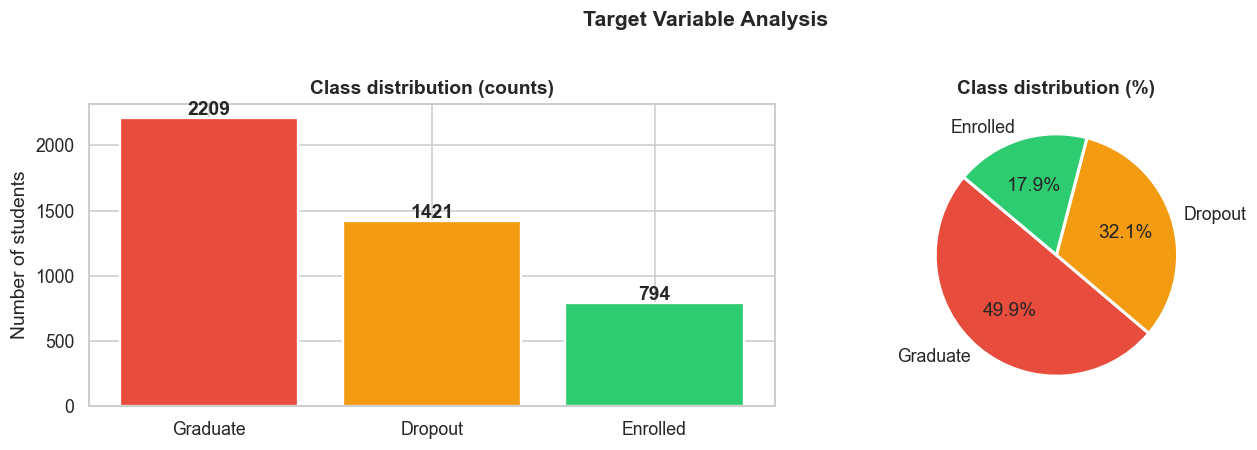

In [7]:
target_counts = df['Target'].value_counts()
target_pct    = df['Target'].value_counts(normalize=True) * 100

print('Target variable distribution:')
summary = pd.DataFrame({'Count': target_counts, '% of dataset': target_pct.round(1)})
display(summary)

ratio = target_counts.max() / target_counts.min()
print(f'\nImbalance ratio (majority / minority) : {ratio:.2f}x')
if ratio > 3:
    print('Significant imbalance. Use class_weight or SMOTE')
elif ratio > 1.5:
    print('Moderate imbalance. class_weight="balanced" recommended')
else:
    print('Balanced classes')

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Barplot
bars = axes[0].bar(target_counts.index, target_counts.values, color=PALETTE, edgecolor='white', linewidth=1.5)
axes[0].set_title('Class distribution (counts)', fontweight='bold')
axes[0].set_ylabel('Number of students')
for bar, val in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(val), ha='center', fontweight='bold')

# Camembert
axes[1].pie(target_counts.values, labels=target_counts.index,
            autopct='%1.1f%%', colors=PALETTE, startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class distribution (%)', fontweight='bold')

plt.suptitle('Target Variable Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Numerical Variable Analysis

We examine the distribution of each numerical variable, separated by target class. This analysis allows us to:

- Identify which variables discriminate well between classes (good predictive features)
- Detect skewness that might require a transformation
- Identify outliers

In [8]:
# Select relevant numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Number of numerical variables: {len(numerical_cols)}')

#  Descriptive statistics grouped by Target
key_num_cols = [
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (approved)',
    'Age at enrollment',
    'Admission grade',
    'Previous qualification (grade)'
]

print('\nMean values by class (key variables)')
display(df.groupby('Target')[key_num_cols].mean().round(2)
    .style.background_gradient(cmap='RdYlGn', axis=0))

Number of numerical variables: 36

Mean values by class (key variables)


,Curricular units 1st sem (grade),Curricular units 2nd sem (grade),Curricular units 1st sem (approved),Curricular units 2nd sem (approved),Age at enrollment,Admission grade,Previous qualification (grade)
Target,,,,,,,
Dropout,7.260000,5.900000,2.550000,1.940000,26.070000,124.960000,131.110000
Enrolled,11.130000,11.120000,4.320000,4.060000,22.370000,125.530000,131.210000
Graduate,12.640000,12.700000,6.230000,6.180000,21.780000,128.790000,134.080000


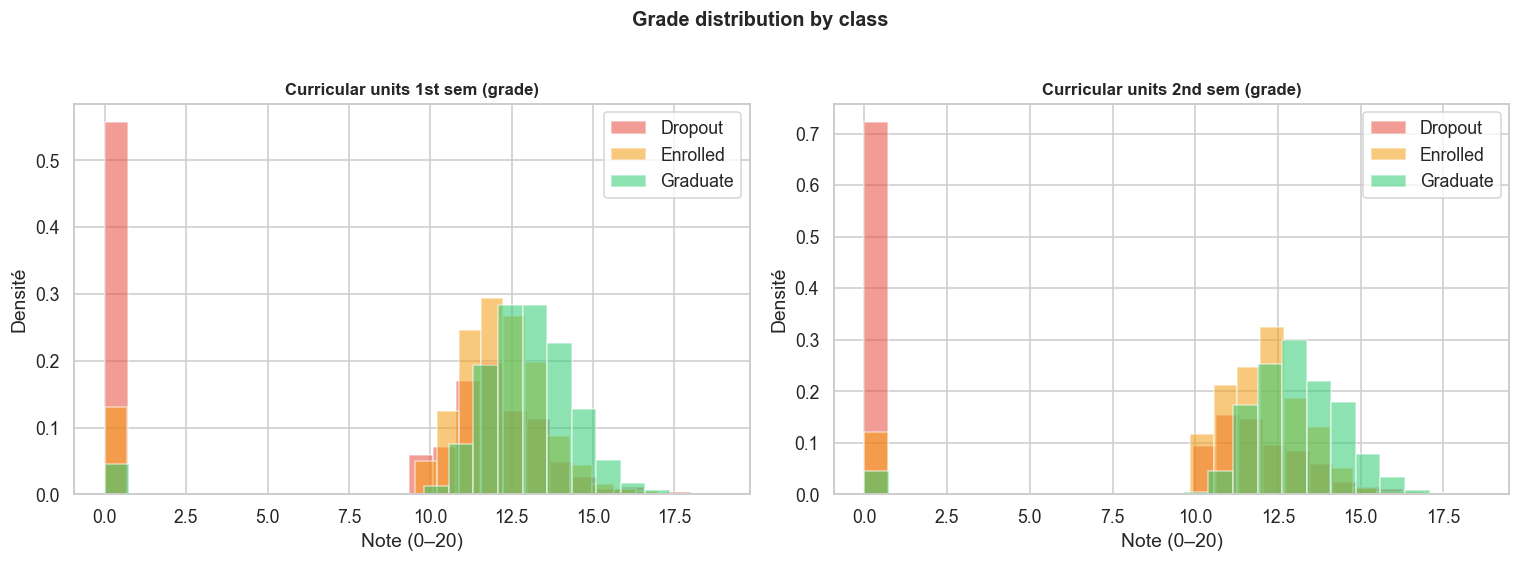

Observation: Students who drop out tend to have lower grades
Grades will likely be among the most important features


In [9]:
#Grade distributions by class
grade_cols = [
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)'
]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, grade_cols):
    for label, color in CLASS_COLORS.items():
        subset = df[df['Target'] == label][col]
        ax.hist(subset, bins=25, alpha=0.55, color=color, label=label, density=True)
    ax.set_title(col, fontweight='bold', fontsize=11)
    ax.set_xlabel('Note (0–20)')
    ax.set_ylabel('Densité')
    ax.legend()

plt.suptitle('Grade distribution by class', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('Observation: Students who drop out tend to have lower grades')
print('Grades will likely be among the most important features')

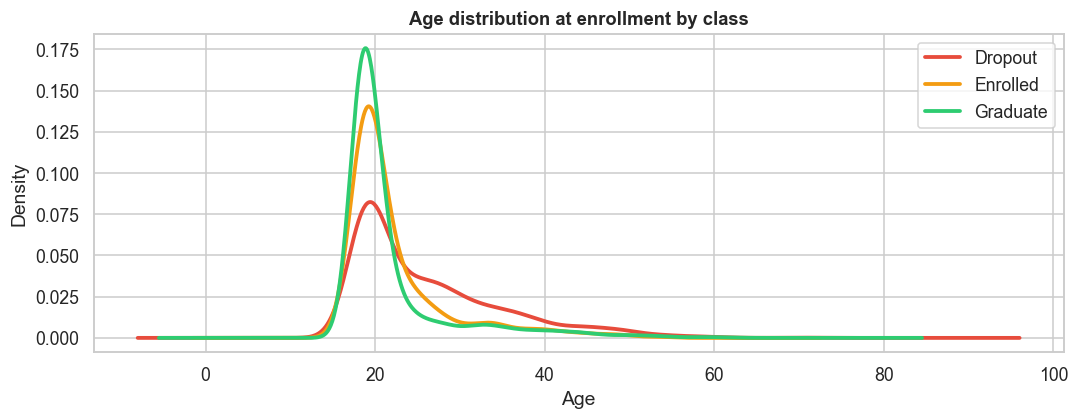

Observation: Older students (>25 years) tend to drop out more often


In [10]:
# Age distribution by class
fig, ax = plt.subplots(figsize=(10, 4))
for label, color in CLASS_COLORS.items():
    df[df['Target'] == label]['Age at enrollment'].plot(
        kind='kde', ax=ax, label=label, color=color, linewidth=2.5
    )
ax.set_title('Age distribution at enrollment by class', fontweight='bold', fontsize=12)
ax.set_xlabel('Age')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()
print('Observation: Older students (>25 years) tend to drop out more often')

---
## 9. Outlier Detection

Outliers are extreme values that deviate significantly from the normal distribution. They can:

- **Disrupt normalization** (Standard Scaler is sensitive to outliers)
- **Bias logistic regression** (gradient-based)
- **Not affect trees** (Random Forest and XGBoost are robust)

The IQR (Interquartile Range) method is used (the standard statistical method)

In [11]:
def count_outliers_iqr(series):
    """Counts outliers using the 1.5×IQR rule (box plot whisker rule)"""
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((series < lower) | (series > upper)).sum()
    return n_out, lower, upper

outlier_cols = [
    'Age at enrollment', 'Admission grade',
    'Previous qualification (grade)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Unemployment rate', 'Inflation rate', 'GDP'
]

print('Outlier Detection (IQR method)')
outlier_report = []
for col in outlier_cols:
    if col in df.columns:
        n_out, lo, hi = count_outliers_iqr(df[col])
        pct = n_out / len(df) * 100
        outlier_report.append({'Feature': col, 
                                'N outliers': n_out,
                                '% outliers': round(pct, 2),
                                'Lower bound': round(lo, 2),
                                'Upper bound': round(hi, 2)})
outlier_df = pd.DataFrame(outlier_report).sort_values('N outliers', ascending=False)
display(outlier_df)

Outlier Detection (IQR method)


,Feature,N outliers,% outliers,Lower bound,Upper bound
4,Curricular units 2nd sem (grade),877,19.820,6.880,17.210
3,Curricular units 1st sem (grade),726,16.410,7.400,17.000
0,Age at enrollment,441,9.970,10.000,34.000
2,Previous qualification (grade),179,4.050,102.500,162.500
1,Admission grade,86,1.940,92.550,160.150
5,Unemployment rate,0,0.000,2.650,20.650
6,Inflation rate,0,0.000,-3.150,6.050
7,GDP,0,0.000,-6.940,7.020


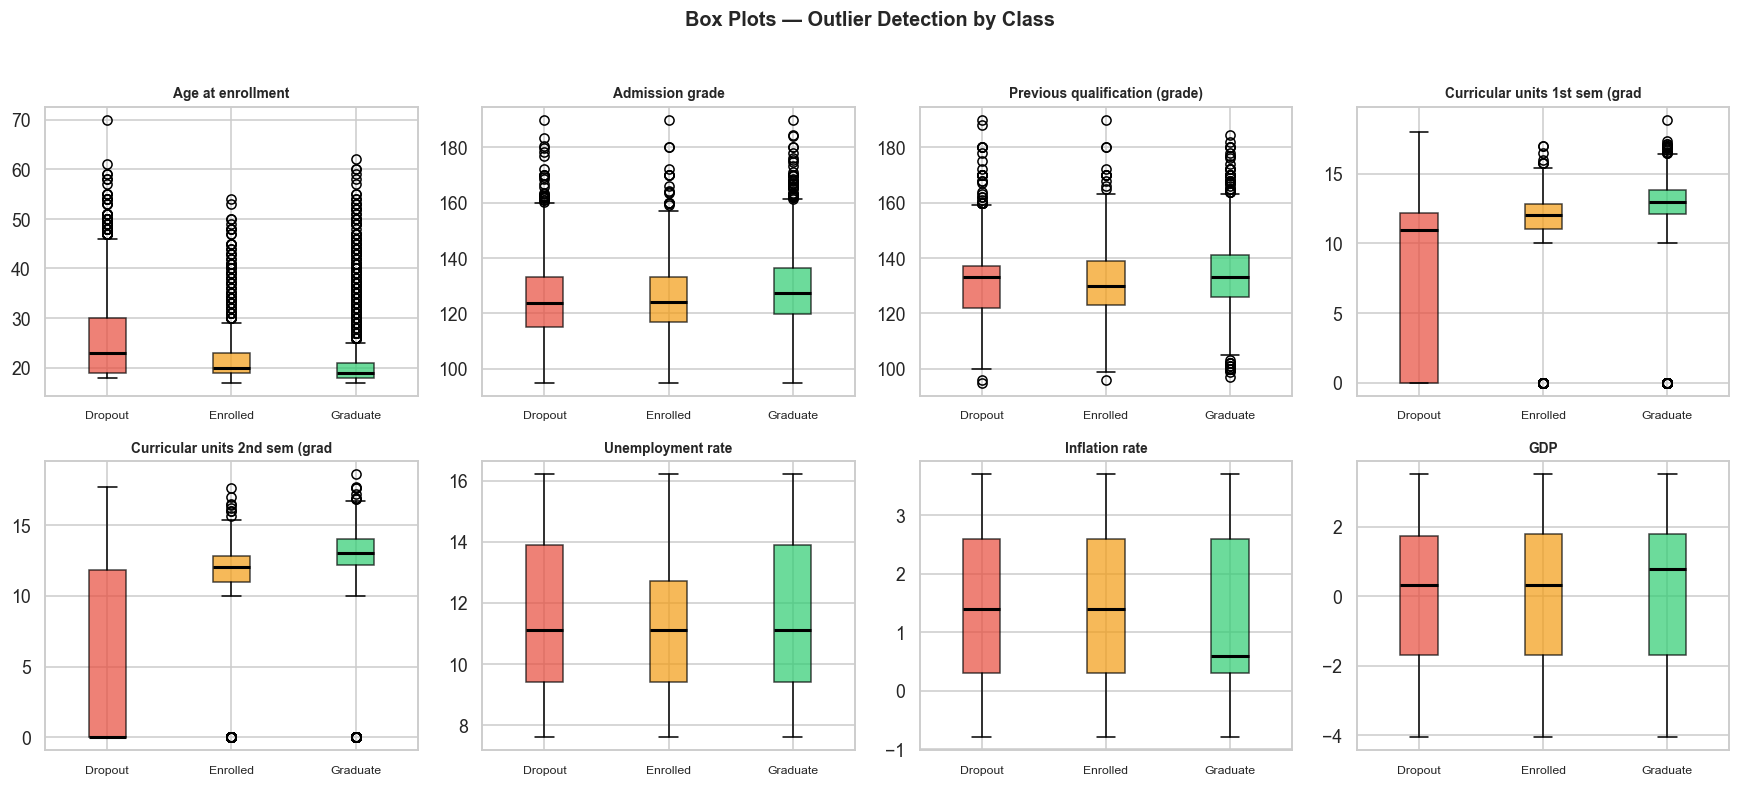

Observation: Age outliers correspond to adult students returning to education
These values are legitimate, not data entry errors
Strategy: use RobustScaler or Winsorization in Notebook 02.


In [12]:
# Boxplots to visualize outliers
plot_cols = [c for c in outlier_cols if c in df.columns]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, col in zip(axes, plot_cols):
    data_to_plot = [df[df['Target'] == lbl][col].dropna() for lbl in CLASS_COLORS]
    bp = ax.boxplot(data_to_plot, patch_artist=True, labels=list(CLASS_COLORS.keys()),
                    medianprops={'color': 'black', 'linewidth': 2})
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(col[:30], fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', labelsize=8)

for ax in axes[len(plot_cols):]:
    ax.set_visible(False)

plt.suptitle('Box Plots — Outlier Detection by Class', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Observation: Age outliers correspond to adult students returning to education')
print('These values are legitimate, not data entry errors')
print('Strategy: use RobustScaler or Winsorization in Notebook 02.')

---
## 10. Analysis of Categorical Variables

Some variables stored as integers are actually categorical codes (eg, marital status: 1=single, 2=married). These must be identified to choose the correct encoding strategy in Notebook 02.

In [13]:
#Identification of hidden categorical variables
print('Variables with few unique values (potentially categorical) :')
cat_candidates = []
for col in df.select_dtypes(include=[np.number]).columns:
    n_unique = df[col].nunique()
    if n_unique <= 20 and col != 'Target_encoded':
        cat_candidates.append({'Column': col, 'N unique values': n_unique,
                                'Values': sorted(df[col].unique().tolist())})

cat_df = pd.DataFrame(cat_candidates).sort_values('N unique values')
display(cat_df)
print(f'\n {len(cat_df)} columns may require one-hot or ordinal encoding')

Variables with few unique values (potentially categorical) :


,Column,N unique values,Values
6,Displaced,2,"[0, 1]"
7,Educational special needs,2,"[0, 1]"
4,Daytime/evening attendance\t,2,"[0, 1]"
12,International,2,"[0, 1]"
11,Scholarship holder,2,"[0, 1]"
10,Gender,2,"[0, 1]"
9,Tuition fees up to date,2,"[0, 1]"
8,Debtor,2,"[0, 1]"
0,Marital status,6,"[1, 2, 3, 4, 5, 6]"
2,Application order,8,"[0, 1, 2, 3, 4, 5, 6, 9]"



 20 columns may require one-hot or ordinal encoding


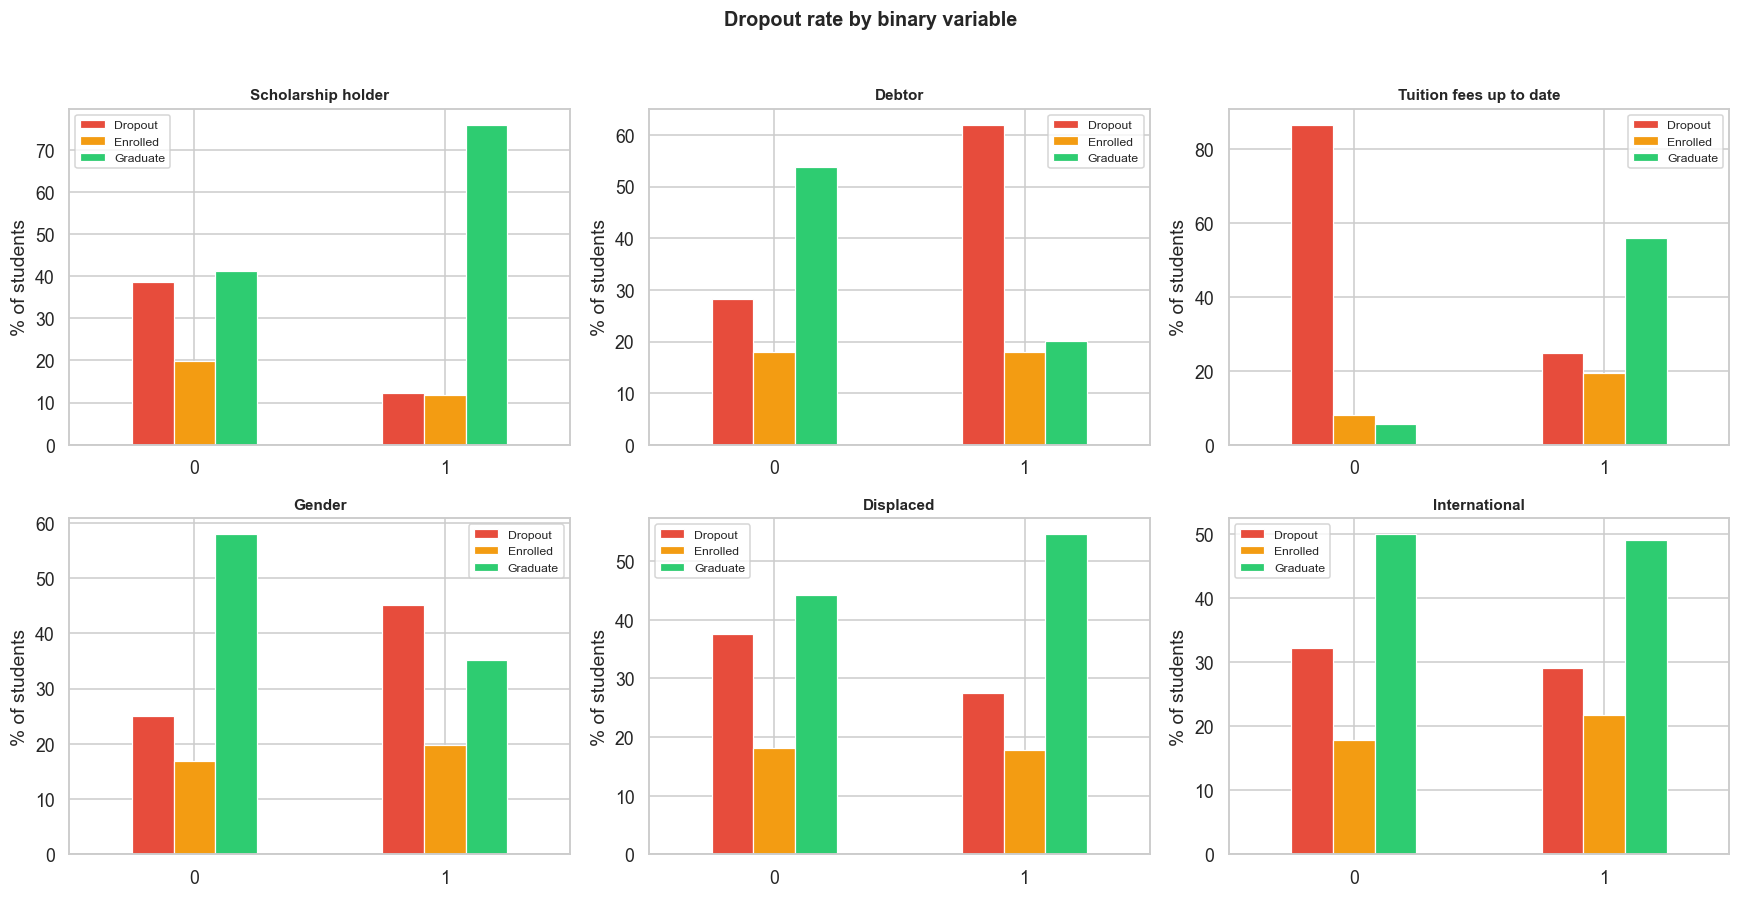

Observation: Debtors (Debtor = 1) and students with unpaid tuition
(Tuition fees up to date = 0) have dropout rates about 2× higher


In [14]:
# TDropout rate by key categorical variables
binary_features = [
    'Scholarship holder', 'Debtor',
    'Tuition fees up to date', 'Gender',
    'Displaced', 'International'
]

binary_features_present = [f for f in binary_features if f in df.columns]

n_cols = 3
n_rows = (len(binary_features_present) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for ax, feat in zip(axes, binary_features_present):
    cross = pd.crosstab(df[feat], df['Target'], normalize='index') * 100
    cross.plot(kind='bar', ax=ax, color=PALETTE, edgecolor='white', linewidth=0.8)
    ax.set_title(feat, fontweight='bold', fontsize=10)
    ax.set_ylabel('% of students')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(fontsize=8)

for ax in axes[len(binary_features_present):]:
    ax.set_visible(False)

plt.suptitle('Dropout rate by binary variable', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Observation: Debtors (Debtor = 1) and students with unpaid tuition')
print('(Tuition fees up to date = 0) have dropout rates about 2× higher')

---
## 11. Correlation Analysis

The correlation matrix allows us to identify:

- **Features strongly correlated with the target** (good predictors)
- **Multicollinearity** between features (two features that carry the same information)

A Pearson correlation close to +1 or -1 indicates a strong linear relationship.

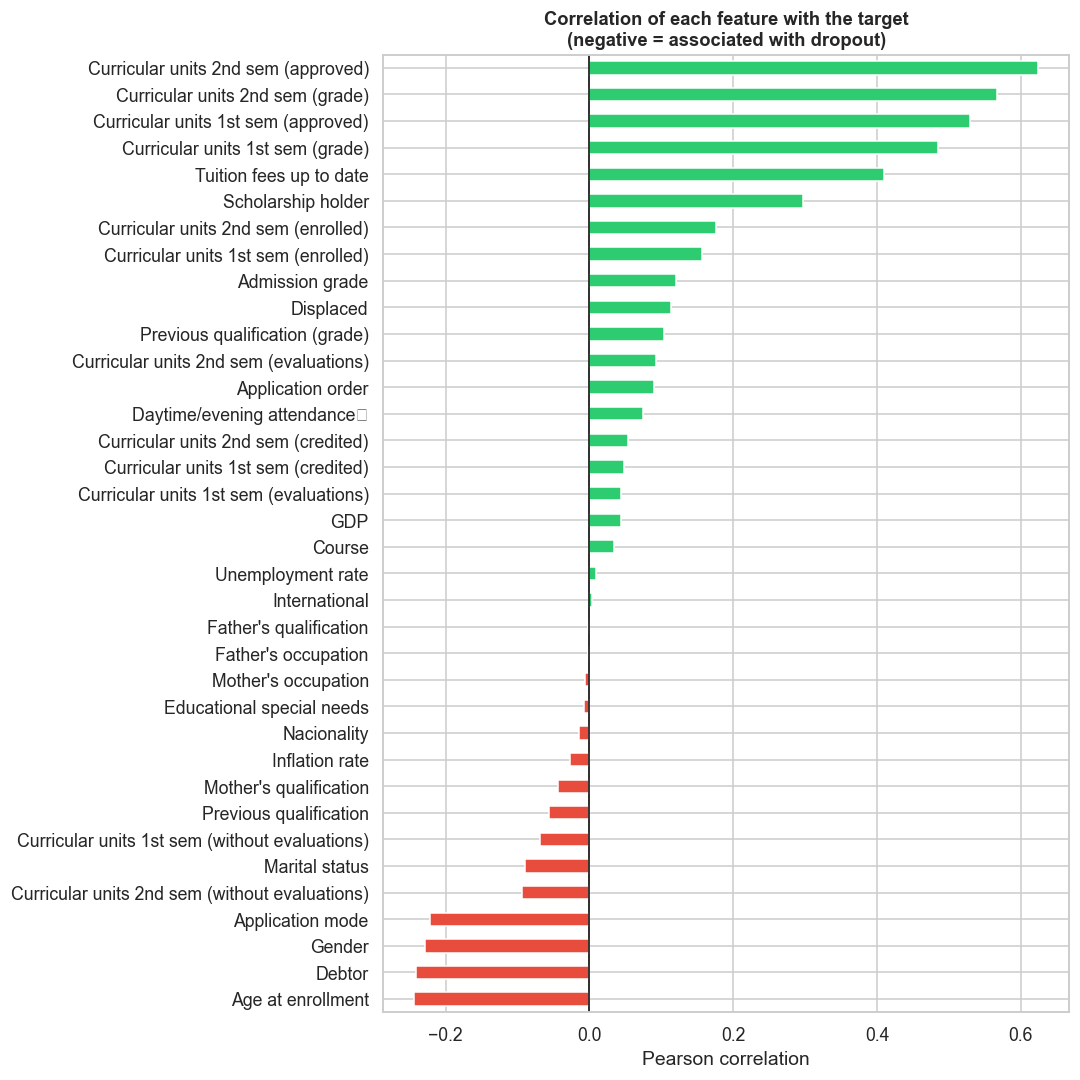

Top 5 features positively correlated with Graduate:
Tuition fees up to date               0.410
Curricular units 1st sem (grade)      0.485
Curricular units 1st sem (approved)   0.529
Curricular units 2nd sem (grade)      0.567
Curricular units 2nd sem (approved)   0.624

Top 5 features negatively correlated (associated with Dropout):
Age at enrollment                                -0.243
Debtor                                           -0.241
Gender                                           -0.229
Application mode                                 -0.222
Curricular units 2nd sem (without evaluations)   -0.094


In [15]:
#Temporary encoding of the target for correlation analysis
df_corr = df.copy()
df_corr['Target_num'] = df['Target'].map({'Dropout': 0, 'Enrolled': 1, 'Graduate': 2})

# Correlation with the target variable
corr_with_target = df_corr.select_dtypes(include=[np.number]).corr()['Target_num']
corr_with_target = corr_with_target.drop('Target_num').sort_values()

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#E74C3C' if x < 0 else '#2ECC71' for x in corr_with_target]
corr_with_target.plot(kind='barh', ax=ax, color=colors)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_title('Correlation of each feature with the target\n(negative = associated with dropout)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Pearson correlation')
plt.tight_layout()
plt.show()

print('Top 5 features positively correlated with Graduate:')
print(corr_with_target.tail(5).to_string())
print('\nTop 5 features negatively correlated (associated with Dropout):')
print(corr_with_target.head(5).to_string())

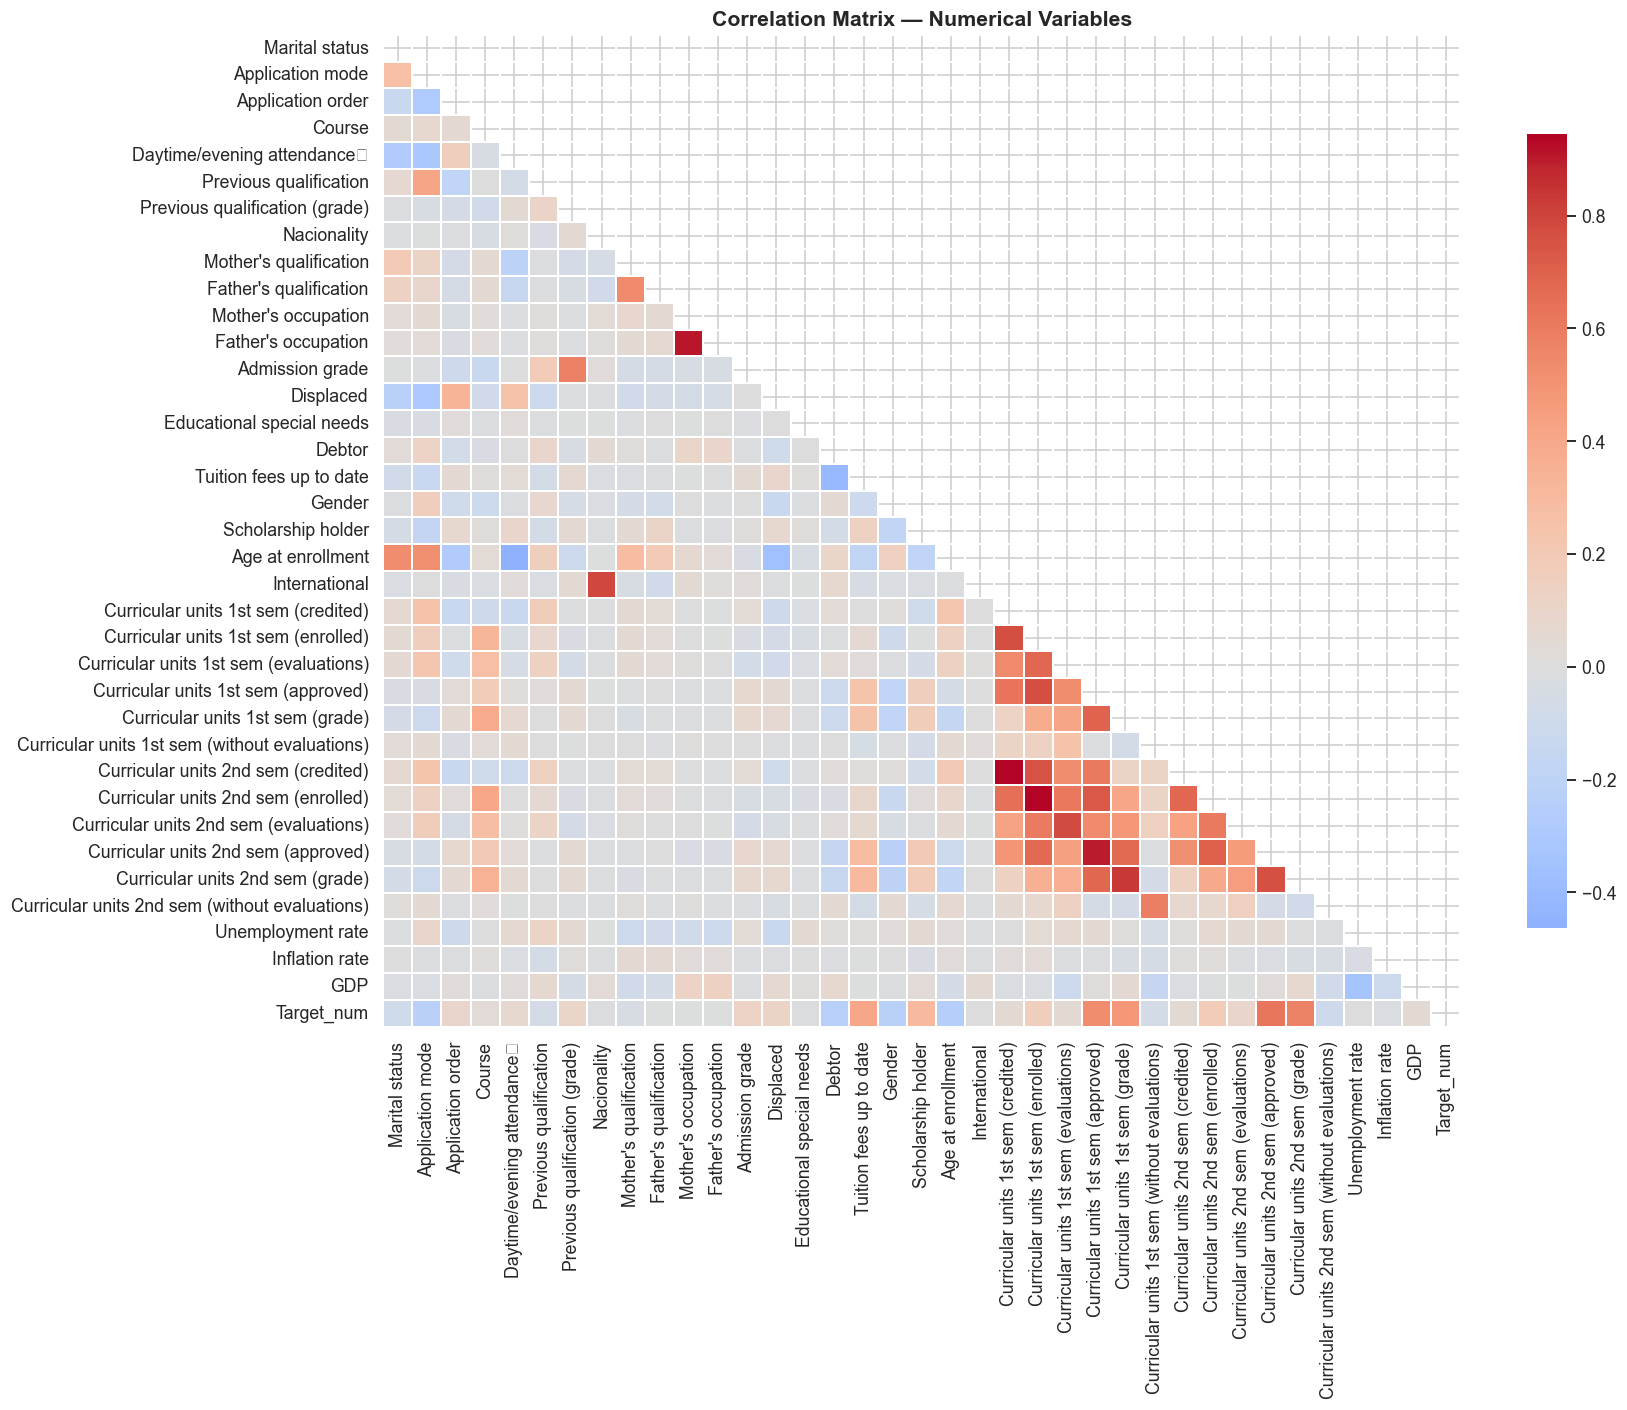


Pairs of strongly correlated features (|r| > 0.8)


,Feature 1,Feature 2,Correlation
1,Curricular units 1st sem (credited),Curricular units 2nd sem (credited),0.945
2,Curricular units 1st sem (enrolled),Curricular units 2nd sem (enrolled),0.943
0,Mother's occupation,Father's occupation,0.910
3,Curricular units 1st sem (approved),Curricular units 2nd sem (approved),0.904
4,Curricular units 1st sem (grade),Curricular units 2nd sem (grade),0.837


 These pairs will be handled during feature selection in Notebook 02


In [16]:
# Correlation heatmap between numerical features
num_df = df_corr.select_dtypes(include=[np.number])
corr_matrix = num_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(16, 13))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm',
            center=0, linewidths=0.2, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Numerical Variables', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Highly correlated pairs (|r| > 0.8) — multicollinearity
print('\nPairs of strongly correlated features (|r| > 0.8)')
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.8:
            high_corr.append({'Feature 1': corr_matrix.columns[i],
                               'Feature 2': corr_matrix.columns[j],
                               'Correlation': round(r, 3)})
if high_corr:
    display(pd.DataFrame(high_corr).sort_values('Correlation', key=abs, ascending=False))
    print(' These pairs will be handled during feature selection in Notebook 02')
else:
    print('No strong multicollinearity detected (|r| ≤ 0.8 for all pairs)')

---
## 12. Economic Variables

The dataset includes macroeconomic variables (unemployment rate, inflation, GDP) that capture the economic context at the time of enrollment. These variables can influence dropout decisions.

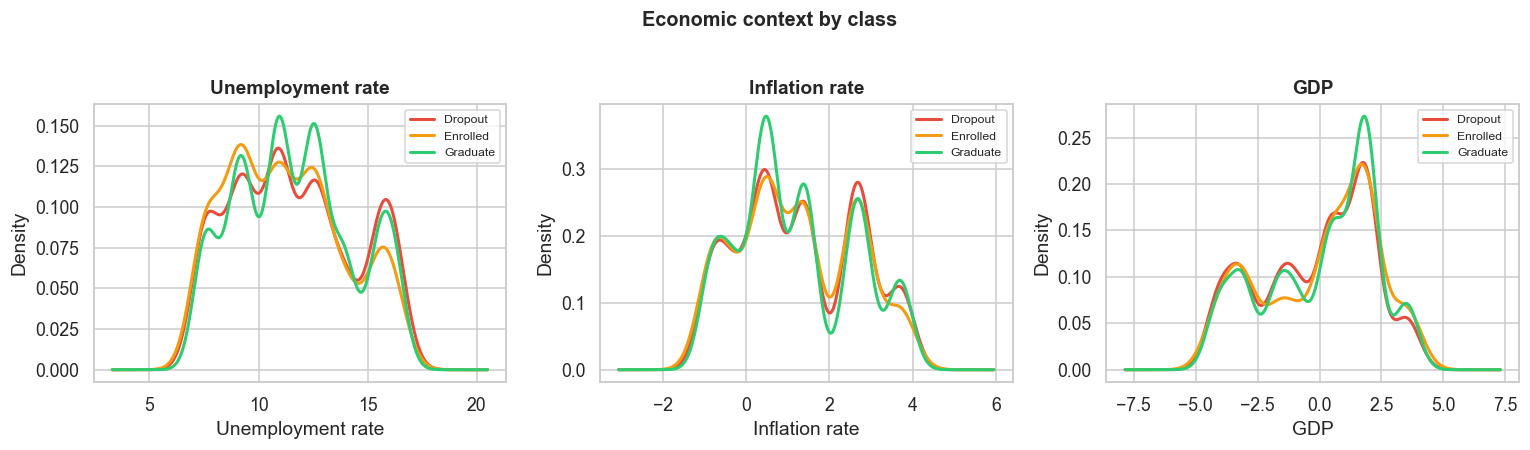

In [17]:
eco_cols = ['Unemployment rate', 'Inflation rate', 'GDP']
eco_cols_present = [c for c in eco_cols if c in df.columns]

if eco_cols_present:
    fig, axes = plt.subplots(1, len(eco_cols_present), figsize=(14, 4))
    if len(eco_cols_present) == 1:
        axes = [axes]
    for ax, col in zip(axes, eco_cols_present):
        for label, color in CLASS_COLORS.items():
            df[df['Target'] == label][col].plot(
                kind='kde', ax=ax, label=label, color=color, linewidth=2
            )
        ax.set_title(col, fontweight='bold')
        ax.set_xlabel(col)
        ax.legend(fontsize=8)
    plt.suptitle('Economic context by class', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

---
## 13. EDA Synthesis :Decisions for Notebook 02

This section summarizes all observations and the resulting preprocessing decisions.

In [18]:
print('=' * 70)
print('EDA SUMMARY — PREPROCESSING DECISIONS (Notebook 02)')
print('=' * 70)

decisions = [
    ('Missing values',     'None → No imputation required'),
    ('Duplicates',         'Checked → Removed if present'),
    ('Class imbalance',    'Moderate (2.78x) → class_weight="balanced"'),
    ('Outliers (age)',     'Legitimate → RobustScaler recommended'),
    ('Categorical vars',   'One-Hot encoding for nominal features (Course, etc.)'),
    ('Scaling',            'StandardScaler for LR, not necessary for RF/XGB'),
    ('Feature Engineering','5 new features (grade trend, success rate)'),
    ('Feature Selection',  'Selection based on RF importance after engineering'),
    ('Metrics',            'Weighted F1-score + AUC-ROC + Confusion Matrix')
]
for i, (aspect, decision) in enumerate(decisions, 1):
    print(f'  {i:2d}. {aspect:<25s} → {decision}')
print('\nMost discriminative features identified:')
print('   → 1st and 2nd semester grades (strongest separation between classes)')
print('   → Approved curricular units (direct correlation with progression)')
print('   → Tuition fees up to date (financial signal)')
print('   → Age at enrollment (adult student profile = higher risk)')

EDA SUMMARY — PREPROCESSING DECISIONS (Notebook 02)
   1. Missing values            → None → No imputation required
   2. Duplicates                → Checked → Removed if present
   3. Class imbalance           → Moderate (2.78x) → class_weight="balanced"
   4. Outliers (age)            → Legitimate → RobustScaler recommended
   5. Categorical vars          → One-Hot encoding for nominal features (Course, etc.)
   6. Scaling                   → StandardScaler for LR, not necessary for RF/XGB
   7. Feature Engineering       → 5 new features (grade trend, success rate)
   8. Feature Selection         → Selection based on RF importance after engineering
   9. Metrics                   → Weighted F1-score + AUC-ROC + Confusion Matrix

Most discriminative features identified:
   → 1st and 2nd semester grades (strongest separation between classes)
   → Approved curricular units (direct correlation with progression)
   → Tuition fees up to date (financial signal)
   → Age at enrollment (adult